# 03 — Classificação de trajetórias (CMAP) e avaliação

**Executar uma vez por cenário** (altere `CENARIO`). Substitui `CMAP_FUNCTIONS.ipynb`, `CMAP_C4_C5.R`, `trajectory_assessment.R` e `CMAP_Assessment_*.R`.

O cenário é definido inteiramente no config:
- uma entrada por data, com o raster de verossimilhança, o tipo (`direta` ou `log`), as classes das bandas, a máscara e a validação;
- as matrizes de transição.

Para variar a modelagem SAR (C2 com Gama HH, Par de intensidades etc.), basta apontar a data SAR para o arquivo `verossimilhanca/<modelo>.tif` correspondente.

| Etapa | Conteúdo | Dissertação |
|---|---|---|
| 1 | verificação dos rasters e da tabela de trajetórias $P(s)$ | Eq. 2.12 |
| 2 | CMAP e MaxVer (mesmas verossimilhanças, todas as transições permitidas) | Eq. 2.11; Seção 4.3.2 |
| 3 | trajetórias impossíveis (MaxVer × CMAP) | Tabelas 5.7–5.9 |
| 4 | discordância MaxVer × CMAP por data e na trajetória | Tabelas 5.7–5.9 |
| 5 | acurácia por data: 1000 reamostragens de 70% da validação, estratificadas, com reposição | Seção 4.3.2 |

**Gravação:** `03_cmap.xlsx` (todas as tabelas), `CMAP.tif` e `MaxVer.tif` (uma banda por data); os demais rasters são opcionais.

> ⚠️ **Máscara de nuvens (`MASK_MODE`):** no `CMAP_classifier` do R, a verossimilhança da data nublada **entra no cálculo** e o pixel só é zerado na saída daquela data (`'output'`, que reproduz o R pixel a pixel). Com `'ignore'`, a data nublada deixa de influenciar a trajetória naquele pixel. Numa cena fictícia, isso alterou 6% da classificação de uma data **sem** nuvem.

## Parâmetros

In [1]:
CONFIG = 'exemplo/config_exemplo.json'
CENARIO = 'C2_par_intensidade'

MASK_MODE = 'output'          # 'output' (como no R) | 'ignore'
N_ITER_AVALIACAO = 200   # reamostragens da validação (dissertação: 1000)
PROP_AVALIACAO = 0.7          # proporção por classe (dissertação: 70%; o script CMAP_Assessment usava 0.1)
COM_REPOSICAO = True          # dissertação: "com reposição"
NORMALIZAR_METRICAS = True

GRAVAR_DISCORDANCIA = True    # raster com o nº de datas em que MaxVer e CMAP discordam
GRAVAR_TRAJECTORY_IDS = False
GRAVAR_LOG_POSTERIOR = False
SALVAR_FIGURAS = False

## Configuração do cenário

In [2]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))      # pasta que contém sar_classification

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sar_classification import (autocorrelation as ac, sampling, samples as smp, fitting as fit,
                                separability as sep, models as mdl, validation as val, raster_io as rio,
                                transitions as trn, cmap, trajectory_assessment as ta, plots, reporting)

with open(CONFIG, encoding='utf-8') as f:
    cfg = json.load(f)
RESULTADOS = Path(cfg['raiz_resultados'])
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

cen = cfg['cenarios'][CENARIO]
resolve = lambda p: None if p in (None, '0', 0) else str(p).replace('{resultados}', str(RESULTADOS))
DATAS = list(cen['datas'])
d_cfg = [cen['datas'][d] for d in DATAS]
VEROSSIMILHANCAS = [resolve(d['verossimilhanca']) for d in d_cfg]
EM_LOG = [d['tipo'] == 'log' for d in d_cfg]
MASCARAS = [resolve(d.get('mascara')) for d in d_cfg]
NIVEIS, LEGENDA_FINAL = cfg['niveis_hierarquicos'], cfg.get('legenda_final') or {}

OUT = RESULTADOS / 'cmap' / CENARIO
OUT.mkdir(parents=True, exist_ok=True)
pdf = reporting.open_pdf(OUT / 'figuras_03.pdf') if SALVAR_FIGURAS else None
tabelas = {}
pd.DataFrame({'data': DATAS, 'verossimilhanca': VEROSSIMILHANCAS, 'em_log': EM_LOG, 'mascara': MASCARAS})

,data,verossimilhanca,em_log,mascara
0,2007,/home/claude/projeto/exemplo/dados/likelihoods...,False,/home/claude/projeto/exemplo/dados/cloud_mask_...
1,2008,/home/claude/projeto/exemplo/resultados/2008/v...,True,NaN
2,2009,/home/claude/projeto/exemplo/dados/likelihoods...,False,NaN


## 1. Verificação dos dados e trajetórias

Rasters sem nome nas bandas (gerados pelo R) usam `classes_bandas` do config. Os gerados pelo notebook 02 já trazem o nome das classes.

In [3]:
CLASSES_BANDAS = []
for d, p in zip(d_cfg, VEROSSIMILHANCAS):
    CLASSES_BANDAS.append(d['classes_bandas'] if d.get('classes_bandas') else cmap.read_bands_config([p])[0])
assert rio.verify_rasters(VEROSSIMILHANCAS, CLASSES_BANDAS), 'Rasters incompatíveis.'

if cen.get('tabela_trajetorias'):            # tabela pronta do R (ex.: pesos_C4_C5.txt)
    trajetorias = trn.read_trajectory_table(resolve(cen['tabela_trajetorias']), CLASSES_BANDAS)
else:                                         # matrizes de transição (P(s) calculado aqui)
    trajetorias = trn.create_transition_matrix_table([resolve(p) for p in cen['transicoes']],
                                                     has_labels=cen.get('transicoes_com_rotulos', True))
for t, (d, cb) in enumerate(zip(DATAS, CLASSES_BANDAS)):
    estagio = set(trajetorias[f'Stage_{t + 1}'])
    if estagio != set(cb):
        print(f'Aviso — {d}: classes da matriz {sorted(estagio)} ≠ classes das bandas {sorted(cb)}')
CODIGOS = cmap.default_class_codes(sorted(set().union(*map(set, CLASSES_BANDAS))))
LEGENDA = {v: k for k, v in CODIGOS.items()}
print('Códigos de saída:', CODIGOS)

                       arquivo  linhas  colunas  bandas   dtype  nodata        crs                                  descricoes
likelihoods_2007_resampled.tif     100      150       6 float32     NaN EPSG:31981        [None, None, None, None, None, None]
           par_intensidade.tif     100      150      10 float32     NaN EPSG:31981 [AP, AC, FD, FP, PL, PS, SE, VS1, VS2, VS3]
likelihoods_2009_resampled.tif     100      150       6 float32     NaN EPSG:31981        [None, None, None, None, None, None]
Sucesso: 3 rasters compatíveis (100 linhas x 150 colunas).
Aviso: em '2007-2008.txt', 6 linha(s) não somam 1 (Eq. 2.13) — esperado apenas em matriz de validade.
Aviso: em '2008-2009.txt', 10 linha(s) não somam 1 (Eq. 2.13) — esperado apenas em matriz de validade.
Trajetórias: 360 | P(s) > 0: 164 | inválidas: 196 | P(ω1) uniforme
Códigos de saída: {'AC': 1, 'AG': 2, 'AP': 3, 'F': 4, 'FD': 5, 'FP': 6, 'PA': 7, 'PL': 8, 'PS': 9, 'SE': 10, 'VS1': 11, 'VS2': 12, 'VS3': 13}


## 2. CMAP e MaxVer

In [4]:
res = cmap.cmap_classifier(VEROSSIMILHANCAS, trajetorias, CLASSES_BANDAS, OUT, date_labels=DATAS,
                           class_codes=CODIGOS, input_is_log=EM_LOG, masks=MASCARAS, mask_mode=MASK_MODE,
                           output_layout='stack', save_trajectory_ids=GRAVAR_TRAJECTORY_IDS,
                           save_log_posterior=GRAVAR_LOG_POSTERIOR)
ARQ_CMAP = res['classified']
ARQ_MAXVER = cmap.maxver_from_likelihoods(VEROSSIMILHANCAS, OUT / 'MaxVer.tif', CODIGOS, CLASSES_BANDAS,
                                          date_labels=DATAS, input_is_log=EM_LOG, masks=MASCARAS)
tab = res['trajectory_table']
tabelas['trajetorias'] = tab[tab['final_weight'] > 0].sort_values('n_pixels', ascending=False)
tabelas['contagem_classes_cmap'] = res['class_counts'].reset_index()
tabelas['legenda'] = pd.DataFrame({'Classe': list(CODIGOS), 'ID': list(CODIGOS.values())})
print(f"Trajetórias: {len(tab)} | válidas: {int((tab.final_weight > 0).sum())} | usadas pelo CMAP: {int((tab.n_pixels > 0).sum())}")

  Progresso:  10.4% (17/164)
  Progresso:  20.1% (33/164)
  Progresso:  30.5% (50/164)
  Progresso:  40.2% (66/164)
  Progresso:  50.0% (82/164)
  Progresso:  60.4% (99/164)
  Progresso:  70.1% (115/164)
  Progresso:  80.5% (132/164)
  Progresso:  90.2% (148/164)
  Progresso: 100.0% (164/164)
Pixels válidos: 15000 de 15000 | classificados: 15000
Saídas em: /home/claude/projeto/exemplo/resultados/cmap/C2_par_intensidade
Trajetórias: 360 | válidas: 164 | usadas pelo CMAP: 129


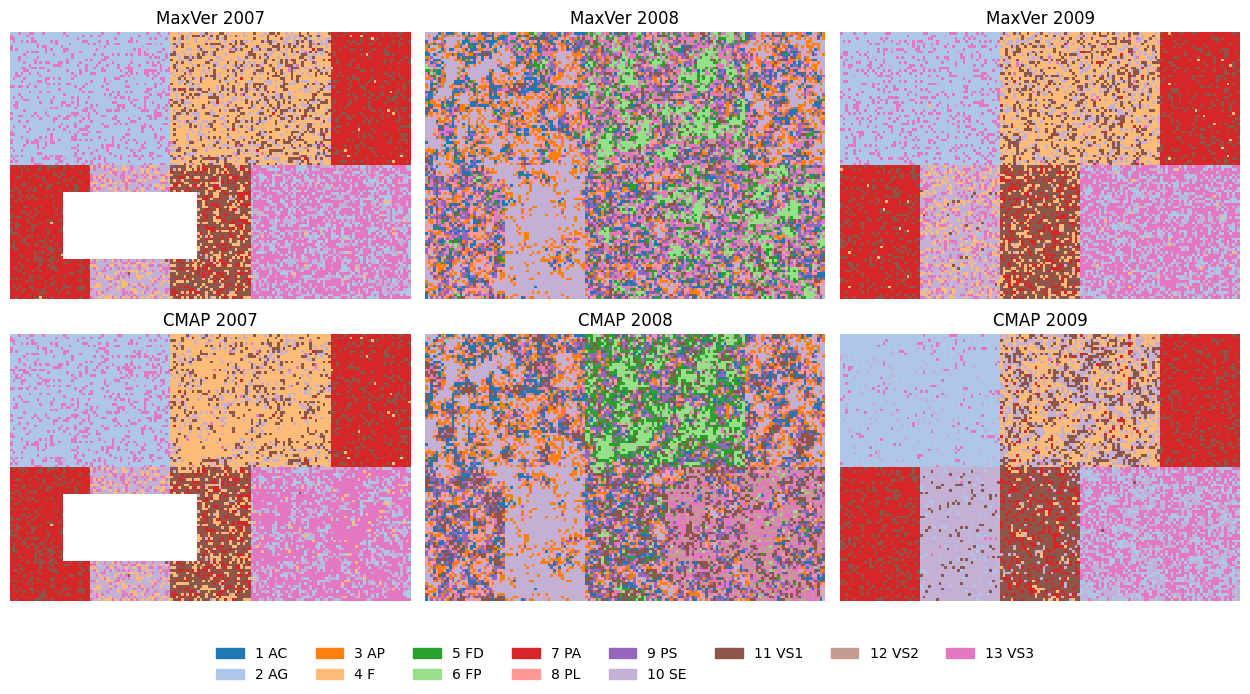

In [5]:
import rasterio
cores = plt.get_cmap('tab20')
fig, axes = plt.subplots(2, len(DATAS), figsize=(4.2 * len(DATAS), 7), squeeze=False)
for r, (nome, arq) in enumerate([('MaxVer', ARQ_MAXVER), ('CMAP', ARQ_CMAP)]):
    with rasterio.open(arq) as s:
        for t in range(len(DATAS)):
            axes[r, t].imshow(np.ma.masked_equal(s.read(t + 1), 0), cmap=cores, vmin=0.5, vmax=20.5, interpolation='nearest')
            axes[r, t].set_title(f'{nome} {DATAS[t]}'); axes[r, t].axis('off')
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=cores(i - 1), label=f'{i} {c}') for c, i in CODIGOS.items()],
           loc='lower center', ncol=min(len(CODIGOS), 8), frameon=False)
plt.tight_layout(rect=(0, 0.07, 1, 1))
if pdf: pdf.savefig(fig)
plt.show()

## 3. Trajetórias impossíveis

Porcentagem de pixels cuja sequência de classes é uma trajetória com $P(s) = 0$, consultada diretamente na tabela de trajetórias usada pelo CMAP. Por construção, o CMAP dá 0%.

In [6]:
imp = {n: ta.impossible_from_table(a, trajetorias, legends=LEGENDA) for n, a in [('MaxVer', ARQ_MAXVER), ('CMAP', ARQ_CMAP)]}
tabelas['trajetorias_impossiveis'] = pd.DataFrame([{'Classificador': n, 'percentual': r['percentage'], 'n_impossiveis': r['n_impossible'],
                                                    'n_validos': r['n_valid']} for n, r in imp.items()])
tabelas['top_impossiveis_maxver'] = imp['MaxVer']['table']
tabelas['trajetorias_impossiveis'].round(3)

,Classificador,percentual,n_impossiveis,n_validos
0,MaxVer,43.527,5985,13750
1,CMAP,0.000,0,13750


## 4. Discordância MaxVer × CMAP

In [7]:
disc = ta.compare_classifications(ARQ_MAXVER, ARQ_CMAP, mask_path=MASCARAS, legend_a=LEGENDA, legend_b=LEGENDA,
                                  date_labels=DATAS, output_path=(OUT / 'discordancia.tif') if GRAVAR_DISCORDANCIA else None)
tabelas['discordancia'] = pd.concat([disc['per_date'], pd.DataFrame([{'date': 'Trajetória', 'percentage': disc['total_percentage']}])],
                                    ignore_index=True)
tabelas['discordancia_histograma'] = disc['histogram'].reset_index()

date  n_valid  n_disagree  percentage
2007    13750        1144       8.320
2008    13750        3421      24.880
2009    13750        2385      17.345
Discordância total (>= 1 data): 43.527%


## 5. Acurácia por data

Para cada data, os mapas CMAP e MaxVer são lidos nos pixels de validação, que podem ser pontos (camada `validacao` do notebook 01) ou polígonos (campo de classe/DN). Em seguida, as métricas são calculadas com `N_ITER_AVALIACAO` reamostragens. Nas datas com `agregacao`, as classes são agregadas na matriz e renomeadas para a legenda final.

> ⚠️ Nos scripts `CMAP_Assessment_*.R`, as datas SAR (2008 e 2010) foram avaliadas com o **arquivo de treino** (`.../train/*_lags_10classes_train.shp`). Aqui, o padrão do config fictício é a camada `validacao`, independente do treino.

In [8]:
avaliacoes = {}
for t, (data, d) in enumerate(zip(DATAS, d_cfg)):
    v = d.get('validacao')
    if not v:
        print(f'{data}: sem validação no config — ignorada.'); continue
    arq = resolve(v['arquivo'])
    if v['tipo'] == 'pontos':
        pts = gpd.read_file(arq, layer=v.get('camada'))
        a = sampling.extract_samples(pts, ARQ_CMAP, band_names=DATAS, class_column=v['coluna'], dropna=False)
        b = sampling.extract_samples(pts, ARQ_MAXVER, band_names=DATAS, class_column=v['coluna'], dropna=False)
    else:
        pol = gpd.read_file(arq)
        pol[v['coluna']] = pol[v['coluna']].astype(str).replace(v.get('nomes') or {})
        a = sampling.extract_polygon_samples(pol, ARQ_CMAP, v['coluna'], band_names=DATAS, dropna=False)
        b = sampling.extract_polygon_samples(pol, ARQ_MAXVER, v['coluna'], band_names=DATAS, dropna=False)
    amostras = pd.DataFrame({'CMAP': a[data].to_numpy(), 'MaxVer': b[data].to_numpy(), 'Class': a['Class'].astype(str).to_numpy()})
    agreg = NIVEIS[d['agregacao']] if d.get('agregacao') else None
    for n in ['CMAP', 'MaxVer']:
        pred = amostras[n].map(lambda c: LEGENDA.get(int(c)) if pd.notna(c) and c > 0 else None)
        avaliacoes[(data, n)] = val.map_accuracy_resampling(pred, amostras['Class'], N_ITER_AVALIACAO, PROP_AVALIACAO,
                                                            COM_REPOSICAO, aggregation=agreg, rename=LEGENDA_FINAL,
                                                            normalize=NORMALIZAR_METRICAS)
    print(f"{data}: {len(amostras)} pixels de validação | OA CMAP = {avaliacoes[(data, 'CMAP')]['overall_accuracy'].mean():.3f} "
          f"| OA MaxVer = {avaliacoes[(data, 'MaxVer')]['overall_accuracy'].mean():.3f}")

g, cl = val.summarize_models({f'{d}|{n}': r for (d, n), r in avaliacoes.items()}, label='chave')
for tb in (g, cl):
    tb[['Data', 'Classificador']] = tb['chave'].str.split('|', expand=True)
    tb.drop(columns='chave', inplace=True)
tabelas['avaliacao_global'] = g[['Data', 'Classificador'] + [c for c in g.columns if c not in ('Data', 'Classificador')]]
tabelas['avaliacao_classes'] = cl[['Data', 'Classificador'] + [c for c in cl.columns if c not in ('Data', 'Classificador')]]
tabelas['avaliacao_iteracoes'] = val.iterations_table({f'{d}|{n}': r for (d, n), r in avaliacoes.items()}, label='Data|Classificador')
tabelas['avaliacao_global'].round(4)

2007: 1960 pixels de validação | OA CMAP = 0.697 | OA MaxVer = 0.651


2008: 5381 pixels de validação | OA CMAP = 0.545 | OA MaxVer = 0.457


2009: 1960 pixels de validação | OA CMAP = 0.686 | OA MaxVer = 0.645


,Data,Classificador,OA_media,OA_dp,OA_ci_lw,OA_ci_up,F1_media,F1_dp,F1_ci_lw,F1_ci_up,n_iteracoes
0,2007,CMAP,0.6968,0.0135,0.6738,0.7237,0.6940,0.0140,0.6703,0.7225,200
1,2007,MaxVer,0.6513,0.0136,0.6280,0.6789,0.6494,0.0138,0.6240,0.6778,200
2,2008,CMAP,0.5450,0.0083,0.5289,0.5598,0.5488,0.0080,0.5332,0.5632,200
3,2008,MaxVer,0.4573,0.0081,0.4404,0.4724,0.4525,0.0079,0.4366,0.4678,200
4,2009,CMAP,0.6862,0.0112,0.6640,0.7076,0.6771,0.0120,0.6530,0.6992,200
5,2009,MaxVer,0.6449,0.0126,0.6235,0.6719,0.6448,0.0128,0.6231,0.6713,200


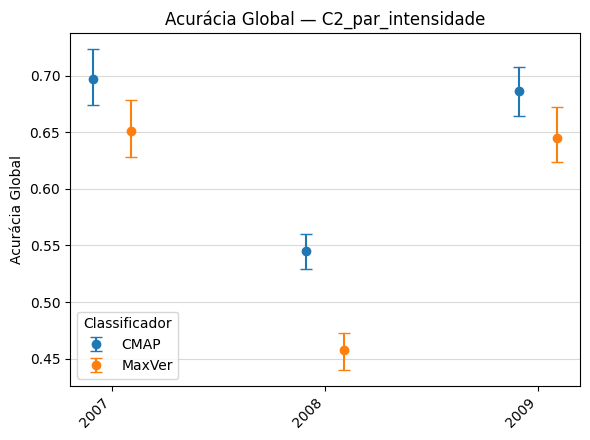

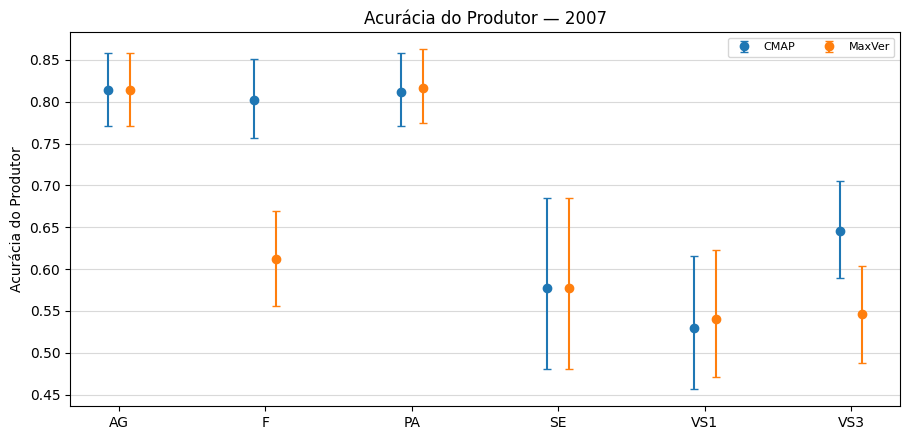

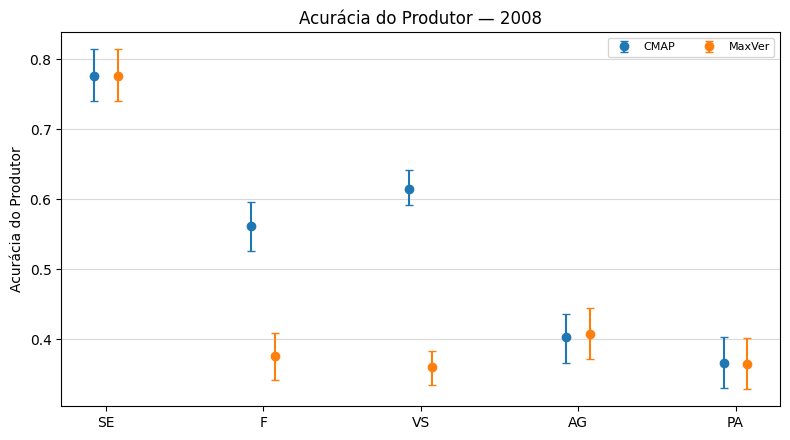

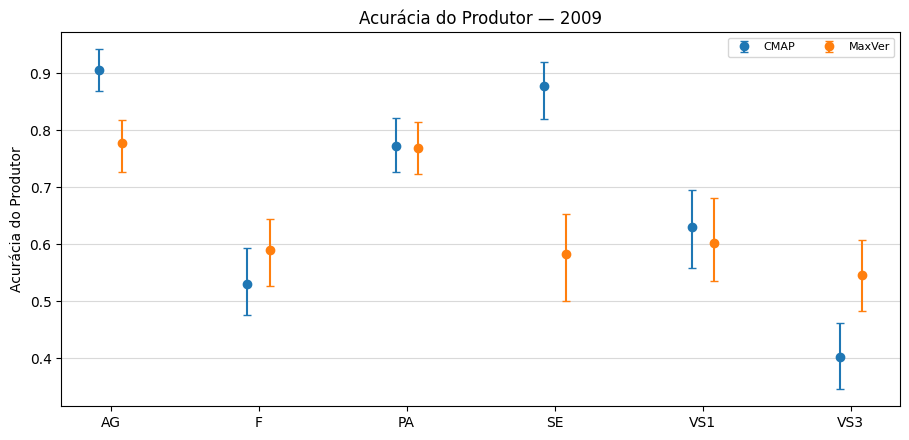

In [9]:
plots.plot_model_comparison(tabelas['avaliacao_global'], 'OA', label='Data', group='Classificador',
                            title=f'Acurácia Global — {CENARIO}', pdf=pdf)
for data in DATAS:
    sub = tabelas['avaliacao_classes'][tabelas['avaliacao_classes'].Data == data]
    if len(sub):
        plots.plot_class_metrics(sub, 'PA', label='Classificador', title=f'Acurácia do Produtor — {data}', pdf=pdf)

## 6. Gravação

In [10]:
tabelas['parametros'] = pd.DataFrame({'parametro': ['CENARIO', 'MASK_MODE', 'N_ITER_AVALIACAO', 'PROP_AVALIACAO', 'COM_REPOSICAO',
                                                     'NORMALIZAR_METRICAS', 'config_do_cenario'],
                                       'valor': [CENARIO, MASK_MODE, N_ITER_AVALIACAO, PROP_AVALIACAO, COM_REPOSICAO,
                                                 NORMALIZAR_METRICAS, json.dumps(cen, ensure_ascii=False)]})
reporting.save_workbook(OUT / '03_cmap.xlsx', tabelas)
if pdf: pdf.close()
print('Arquivos do cenário:', *sorted(p.name for p in OUT.iterdir()), sep='\n  ')

Planilha gravada: /home/claude/projeto/exemplo/resultados/cmap/C2_par_intensidade/03_cmap.xlsx (11 abas: trajetorias, contagem_classes_cmap, legenda, trajetorias_impossiveis, top_impossiveis_maxver, discordancia, discordancia_histograma, avaliacao_global, avaliacao_classes, avaliacao_iteracoes, parametros)
Arquivos do cenário:
  03_cmap.xlsx
  CMAP.tif
  MaxVer.tif
  discordancia.tif
